In [ ]:
from __future__ import annotations
 
import json
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgs
from matplotlib.patches import Ellipse
 
 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Public API
# ─────────────────────────────────────────────────────────────────────────────
 
def analyse_volume_pair(
    # ── Volume input (choose ONE of the three input modes) ────────────────────
 
    # Mode 1 — direct numpy arrays
    vol_xray:        Optional[np.ndarray] = None,
    vol_neutron:     Optional[np.ndarray] = None,
 
    # Mode 2 — explicit file paths
    path_xray:       Optional[Union[str, Path]] = None,
    path_neutron:    Optional[Union[str, Path]] = None,
 
    # Mode 3 — batch manifest + filters
    manifest:        Optional[Union[str, Path, list]] = None,
    phantom:         Optional[str] = None,   # e.g. "composite"
    artifact:        Optional[str] = None,   # e.g. "clean"
    algorithm:       Optional[str] = None,   # e.g. "SART"
 
    # ── Ground-truth phantom (for GT markers and metrics) ─────────────────────
    # Pass any ONE of:
    phantom_obj      = None,        # already-built PhantomData object
    phantom_preset:  Optional[str] = None,  # e.g. "composite"  → auto-built
    phantom_N:       int = 64,              # N used to build phantom_preset
    cache_dir:       Optional[Union[str, Path]] = None,  # SimCache directory
 
    # ── Histogram parameters ──────────────────────────────────────────────────
    bins:            int   = 128,
    x_range:         Optional[Tuple[float, float]] = None,
    n_range:         Optional[Tuple[float, float]] = None,
    log_scale:       bool  = True,
    cmap:            str   = "inferno",
 
    # ── GMM fitting ───────────────────────────────────────────────────────────
    fit_gmm:         bool  = True,
    n_components:    Optional[int] = None,   # None = auto (BIC)
    energy_idx:      int   = 6,              # 80 keV reference for GT lookup
 
    # ── Metrics ───────────────────────────────────────────────────────────────
    compute_metrics: bool  = True,           # Davies-Bouldin, centroid error…
 
    # ── Plot ─────────────────────────────────────────────────────────────────
    show_plot:       bool  = True,
    show_marginals:  bool  = True,
    show_gt_markers: bool  = True,
    show_gmm_ellipses: bool = True,
    figsize:         Tuple[float, float] = (14, 6),
    title:           Optional[str] = None,
    save_fig:        Optional[Union[str, Path]] = None,  # path to save PNG
 
    # ── Verbosity ─────────────────────────────────────────────────────────────
    verbose:         bool  = True,
) -> dict:
    """
    Load a (vol_xray, vol_neutron) pair, compute the bimodal histogram,
    optionally fit a GMM and run cluster-quality metrics, and display a
    publication-quality figure.
 
    Input modes
    -----------
    **Mode 1 — numpy arrays** (fastest; volumes already in memory)::
 
        result = analyse_volume_pair(vol_xray=vx, vol_neutron=vn,
                                     phantom_preset="composite")
 
    **Mode 2 — explicit file paths**::
 
        result = analyse_volume_pair(
            path_xray   = "batch_results/composite/clean/SART/vol_xray.npy",
            path_neutron= "batch_results/composite/clean/SART/vol_neutron.npy",
            phantom_preset="composite",
        )
 
    **Mode 3 — batch manifest lookup** (load from the JSON saved by
    ``batch_reconstruct_all``)::
 
        result = analyse_volume_pair(
            manifest = "batch_results/manifest.json",
            phantom  = "composite",
            artifact = "clean",
            algorithm= "SART",
            phantom_preset="composite",
        )
 
    Ground-truth phantom
    --------------------
    * ``phantom_obj``    — pass an already-built ``PhantomData`` directly.
    * ``phantom_preset`` — auto-build with ``nxs.make_phantom(preset, N)``.
    * ``cache_dir``      — load metadata from a ``SimCache`` directory.
    * If none is provided, GT markers and metrics are skipped with a warning.
 
    Returns
    -------
    dict with keys:
 
    ``hist``        — HistogramResult
    ``gmm``         — GMMFitResult or None
    ``metrics``     — ClusterQualityMetrics or None
    ``phantom_obj`` — PhantomData or None
    ``fig``         — matplotlib Figure or None
    ``vol_xray``    — (N,N,N) float32 [cm^-1]
    ``vol_neutron`` — (N,N,N) float32 [cm^-1]
    ``label``       — descriptive string for the run
    """
 
    import neutron_xray_sim as nxs
    from neutron_xray_sim.histogram import (
        compute_bimodal_histogram,
        evaluate_histogram_quality,
        fit_gmm      as _fit_gmm,
        auto_fit_gmm as _auto_fit_gmm,
    )
 
    # ─── Step 1: resolve volumes ──────────────────────────────────────────────
    vx, vn, label = _resolve_volumes(
        vol_xray, vol_neutron,
        path_xray, path_neutron,
        manifest, phantom, artifact, algorithm,
        verbose,
    )
 
    if title is None:
        title = label
 
    if verbose:
        print(f"[analyse]  {label}")
        print(f"           shape={vx.shape}  dtype={vx.dtype}")
        print(f"           mu_x range [{vx.min():.3f}, {vx.max():.3f}] cm^-1")
        print(f"           mu_n range [{vn.min():.3f}, {vn.max():.3f}] cm^-1")
 
    # ─── Step 2: resolve phantom ──────────────────────────────────────────────
    ph = _resolve_phantom(phantom_obj, phantom_preset, phantom_N,
                          cache_dir, phantom, verbose)
 
    # ─── Step 3: bimodal histogram ────────────────────────────────────────────
    if verbose:
        print(f"           Computing histogram  bins={bins}…")
    hist = compute_bimodal_histogram(vx, vn, bins=bins,
                                     x_range=x_range, n_range=n_range)
    if verbose:
        print(f"           Total voxels: {hist.total_voxels:,}")
 
    # ─── Step 4: GMM fitting ──────────────────────────────────────────────────
    gmm_result = None
    if fit_gmm:
        n_mat = len(ph.materials) if ph is not None else None
        k = n_components or n_mat
        if verbose:
            kstr = str(k) if k else "auto (BIC)"
            print(f"           Fitting GMM  k={kstr}…")
        try:
            if k is not None:
                gmm_result = _fit_gmm(hist, n_components=k)
            else:
                gmm_result = _auto_fit_gmm(hist, min_k=2, max_k=9)
            if verbose:
                print(f"           GMM: k={gmm_result.n_components}  "
                      f"BIC={gmm_result.bic:.0f}  AIC={gmm_result.aic:.0f}")
        except Exception as e:
            warnings.warn(f"GMM fitting failed: {e}")
 
    # ─── Step 5: cluster quality metrics ──────────────────────────────────────
    metrics = None
    if compute_metrics and ph is not None:
        n_mat = len(ph.materials)
        k_met = n_components or n_mat
        if verbose:
            print(f"           Computing metrics  (k={k_met})…")
        try:
            metrics = evaluate_histogram_quality(
                hist, ph,
                n_components = k_met,
                energy_idx   = energy_idx,
                exclude_air  = True,
            )
            if verbose:
                print(f"           Davies-Bouldin    : {metrics.davies_bouldin:.4f}")
                print(f"           Mean centroid err : "
                      f"{metrics.mean_centroid_error:.4f} cm^-1")
                print(f"           Matched phases    : {metrics.n_matched}")
                for mat, err in sorted(metrics.centroid_errors.items()):
                    sx = metrics.sigma_x.get(mat, float("nan"))
                    sn = metrics.sigma_n.get(mat, float("nan"))
                    print(f"             {mat:<18s}: "
                          f"CE={err:.4f}  sigma_x={sx:.4f}  sigma_n={sn:.4f}")
        except Exception as e:
            warnings.warn(f"Metrics failed: {e}")
    elif compute_metrics and ph is None:
        warnings.warn(
            "compute_metrics=True but no phantom provided — "
            "pass phantom_preset, phantom_obj, or cache_dir."
        )
 
    # ─── Step 6: figure ───────────────────────────────────────────────────────
    fig = None
    if show_plot:
        fig = _make_figure(
            hist         = hist,
            gmm          = gmm_result,
            metrics      = metrics,
            ph           = ph,
            vx           = vx,
            vn           = vn,
            title        = title,
            log_scale    = log_scale,
            cmap         = cmap,
            show_marginals   = show_marginals,
            show_gt_markers  = show_gt_markers,
            show_gmm_ellipses= show_gmm_ellipses,
            figsize      = figsize,
            energy_idx   = energy_idx,
        )
        if save_fig:
            fig.savefig(str(save_fig), dpi=150, bbox_inches="tight")
            if verbose:
                print(f"           Figure saved: {save_fig}")
        plt.show()
 
    return {
        "hist":        hist,
        "gmm":         gmm_result,
        "metrics":     metrics,
        "phantom_obj": ph,
        "fig":         fig,
        "vol_xray":    vx,
        "vol_neutron": vn,
        "label":       label,
    }
 
 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Internal helpers
# ─────────────────────────────────────────────────────────────────────────────
 
def _resolve_volumes(vol_xray, vol_neutron,
                     path_xray, path_neutron,
                     manifest, phantom, artifact, algorithm,
                     verbose):
    """Return (vx, vn, label) from whichever input mode was used."""
 
    # Mode 1: arrays given directly
    if vol_xray is not None and vol_neutron is not None:
        return (vol_xray.astype(np.float32),
                vol_neutron.astype(np.float32),
                "direct arrays")
 
    # Mode 2: explicit paths
    if path_xray is not None:
        px = Path(path_xray)
        pn = Path(path_neutron) if path_neutron else \
             px.parent / "vol_neutron.npy"
        if not px.exists():
            raise FileNotFoundError(f"X-ray volume not found: {px}")
        if not pn.exists():
            raise FileNotFoundError(f"Neutron volume not found: {pn}")
        if verbose:
            print(f"[analyse]  Loading from paths:")
            print(f"           X-ray  : {px}")
            print(f"           Neutron: {pn}")
        vx = np.load(str(px)).astype(np.float32)
        vn = np.load(str(pn)).astype(np.float32)
        label = px.parent.name  # e.g. "SART"
        return vx, vn, label
 
    # Mode 3: manifest lookup
    if manifest is not None:
        if isinstance(manifest, (str, Path)):
            with open(manifest) as f:
                entries = json.load(f)
        else:
            entries = manifest  # already a list
 
        # Filter entries
        def _match(e):
            if e.get("modality") != "xray":
                return False
            if e.get("skipped"):
                return False
            if phantom  and e.get("phantom")   != phantom:
                return False
            if artifact and e.get("artifact")  != artifact:
                return False
            if algorithm and e.get("algorithm") != algorithm:
                return False
            return True
 
        matches = [e for e in entries if _match(e)]
 
        if not matches:
            avail_ph  = sorted({e["phantom"]   for e in entries})
            avail_art = sorted({e["artifact"]  for e in entries})
            avail_alg = sorted({e["algorithm"] for e in entries})
            raise ValueError(
                f"No manifest entry matched filters: "
                f"phantom={phantom!r} artifact={artifact!r} algorithm={algorithm!r}\n"
                f"Available phantoms  : {avail_ph}\n"
                f"Available artifacts : {avail_art}\n"
                f"Available algorithms: {avail_alg}"
            )
        if len(matches) > 1:
            raise ValueError(
                f"{len(matches)} entries match the filters — "
                "please be more specific:\n"
                + "\n".join(f"  {e['phantom']}/{e['artifact']}/{e['algorithm']}"
                            for e in matches[:6])
            )
 
        entry  = matches[0]
        px     = Path(entry["path"])
        pn     = px.parent / "vol_neutron.npy"
 
        if not px.exists():
            raise FileNotFoundError(f"X-ray volume not found: {px}")
        if not pn.exists():
            raise FileNotFoundError(f"Neutron volume not found: {pn}")
 
        if verbose:
            print(f"[analyse]  Manifest match: "
                  f"{entry['phantom']}/{entry['artifact']}/{entry['algorithm']}")
            print(f"           X-ray  : {px}")
            print(f"           Neutron: {pn}")
 
        vx  = np.load(str(px)).astype(np.float32)
        vn  = np.load(str(pn)).astype(np.float32)
        label = (f"{entry['phantom']} / {entry['artifact']} / {entry['algorithm']}")
        return vx, vn, label
 
    raise ValueError(
        "No volumes specified.  Use one of:\n"
        "  vol_xray + vol_neutron  (numpy arrays)\n"
        "  path_xray [+ path_neutron]  (file paths)\n"
        "  manifest + phantom + artifact + algorithm  (manifest lookup)"
    )
 
 
def _resolve_phantom(phantom_obj, phantom_preset, phantom_N,
                     cache_dir, phantom_name, verbose):
    """Return a PhantomData or None from whichever source was given."""
    import neutron_xray_sim as nxs
 
    if phantom_obj is not None:
        return phantom_obj
 
    if phantom_preset is not None:
        if verbose:
            print(f"           Building phantom '{phantom_preset}' N={phantom_N}…")
        return nxs.make_phantom(phantom_preset, phantom_N)
 
    if cache_dir is not None:
        try:
            from neutron_xray_sim.io import SimCache
            meta = SimCache(str(cache_dir)).load_phantom_meta()
            if verbose:
                print(f"           Loading phantom '{meta['name']}' "
                      f"N={meta['N']} from cache…")
            return nxs.make_phantom(meta["name"], meta["N"])
        except Exception as e:
            warnings.warn(f"Could not load phantom from cache: {e}")
 
    if phantom_name is not None and phantom_name in nxs.PHANTOM_PRESETS:
        if verbose:
            print(f"           Auto-building phantom '{phantom_name}' "
                  f"N={phantom_N}…")
        return nxs.make_phantom(phantom_name, phantom_N)
 
    return None
 
 
def _make_figure(hist, gmm, metrics, ph, vx, vn,
                 title, log_scale, cmap, show_marginals,
                 show_gt_markers, show_gmm_ellipses, figsize, energy_idx):
    """
    Build the complete analysis figure.
 
    Layout (left to right):
    [1] Bimodal histogram  (with optional marginals, GT markers, GMM ellipses)
    [2] Central XY slice — X-ray volume
    [3] Central XY slice — Neutron volume
    [4] Metrics text panel (if metrics available)
    """
 
    # Decide column count based on what we have
    show_metrics_panel = metrics is not None
    n_right = 2 + (1 if show_metrics_panel else 0)  # slices + optional metrics
 
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    fig.suptitle(title, fontsize=12, y=1.01)
 
    # ── Outer: [histogram | right panels] ────────────────────────────────────
    outer = mgs.GridSpec(1, 2, figure=fig,
                         width_ratios=[1.6, 1.0], wspace=0.06)
 
    # ── Left: histogram (with optional marginals) ─────────────────────────────
    left_sf = fig.add_subfigure(outer[0, 0])
    _draw_histogram_panel(left_sf, hist, gmm, ph, metrics,
                          log_scale, cmap, show_marginals,
                          show_gt_markers, show_gmm_ellipses, energy_idx)
 
    # ── Right: slices + metrics ───────────────────────────────────────────────
    right_sf  = fig.add_subfigure(outer[0, 1])
    right_gs  = mgs.GridSpec(n_right, 1, figure=right_sf,
                              hspace=0.35)
 
    # X-ray slice
    ax_x = right_sf.add_subplot(right_gs[0, 0])
    si   = vx.shape[0] // 2
    vmin, vmax = np.percentile(vx, [1, 99])
    ax_x.imshow(vx[si], cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    ax_x.set_title("X-ray  (central slice)", fontsize=9, color="#4a90d9")
    ax_x.axis("off")
 
    # Neutron slice
    ax_n = right_sf.add_subplot(right_gs[1, 0])
    vmin, vmax = np.percentile(vn, [1, 99])
    ax_n.imshow(vn[si], cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    ax_n.set_title("Neutron  (central slice)", fontsize=9, color="#34a85a")
    ax_n.axis("off")
 
    # Metrics panel
    if show_metrics_panel:
        ax_m = right_sf.add_subplot(right_gs[2, 0])
        ax_m.axis("off")
        _draw_metrics_text(ax_m, metrics)
 
    return fig
 
 
def _draw_histogram_panel(subfig, hist, gmm, ph, metrics,
                           log_scale, cmap, show_marginals,
                           show_gt_markers, show_gmm_ellipses, energy_idx):
    """Draw the 2-D histogram with marginals, GT markers, GMM ellipses."""
 
    if show_marginals:
        gs = subfig.add_gridspec(2, 3,
                                 width_ratios=[4, 1, 0.15],
                                 height_ratios=[1, 4],
                                 hspace=0.0, wspace=0.0)
        ax      = subfig.add_subplot(gs[1, 0])
        ax_top  = subfig.add_subplot(gs[0, 0], sharex=ax)
        ax_rgt  = subfig.add_subplot(gs[1, 1], sharey=ax)
        ax_cb   = subfig.add_subplot(gs[1, 2])
        subfig.add_subplot(gs[0, 1]).set_visible(False)
        subfig.add_subplot(gs[0, 2]).set_visible(False)
    else:
        gs  = subfig.add_gridspec(1, 2, width_ratios=[4, 0.15], wspace=0.0)
        ax  = subfig.add_subplot(gs[0, 0])
        ax_cb = subfig.add_subplot(gs[0, 1])
        ax_top = ax_rgt = None
 
    H      = hist.H.T
    extent = [hist.x_edges[0], hist.x_edges[-1],
              hist.n_edges[0], hist.n_edges[-1]]
    H_plot = np.log1p(H) if log_scale else H
    H_plot = np.ma.masked_where(H == 0, H_plot)
 
    im = ax.imshow(H_plot, origin="lower", extent=extent,
                   aspect="auto", cmap=cmap, interpolation="bilinear")
    ax.set_xlabel(r"$\mu_x$ [cm$^{-1}$]", fontsize=11)
    ax.set_ylabel(r"$\mu_n$ [cm$^{-1}$]", fontsize=11)
    ax.tick_params(labelsize=9)
 
    cbar = plt.colorbar(im, cax=ax_cb)
    cbar.set_label("log(1+counts)" if log_scale else "counts", fontsize=9)
    ax_cb.tick_params(labelsize=7)
 
    # GT markers
    if show_gt_markers and ph is not None:
        mu_x_gt = [m._mu_x_table[energy_idx] for m in ph.materials]
        mu_n_gt = [m.mu_n for m in ph.materials]
        gt_cols = plt.cm.Set1(np.linspace(0, 0.9, len(mu_x_gt)))
        for i, (mx, mn, col) in enumerate(zip(mu_x_gt, mu_n_gt, gt_cols)):
            ax.plot(mx, mn, "D", color="white", markersize=6,
                    markeredgecolor=col, markeredgewidth=1.5, zorder=6)
            sym = ph.materials[i].symbol
            ax.annotate(sym, xy=(mx, mn), xytext=(4, 4),
                        textcoords="offset points",
                        fontsize=8, color="white", fontweight="bold", zorder=7)
 
    # GMM ellipses
    if show_gmm_ellipses and gmm is not None:
        colours = plt.cm.tab10(np.linspace(0, 1, gmm.n_components))
        for k in range(gmm.n_components):
            mu_x, mu_n = gmm.means[k]
            cov        = gmm.covariances[k]
            eigvals, eigvecs = np.linalg.eigh(cov)
            angle  = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
            w      = 2 * 2.0 * np.sqrt(max(eigvals[0], 0))
            h      = 2 * 2.0 * np.sqrt(max(eigvals[1], 0))
            ell    = Ellipse((mu_x, mu_n), width=w, height=h, angle=angle,
                             edgecolor=colours[k], facecolor="none",
                             linewidth=1.6, linestyle="--", zorder=5)
            ax.add_patch(ell)
            ax.plot(mu_x, mu_n, "+", color=colours[k],
                    markersize=9, markeredgewidth=2, zorder=5)
 
    # Top marginal (mu_x, log counts)
    if ax_top is not None:
        x_marg = np.maximum(hist.H.sum(axis=1).astype(float), 0.5)
        ax_top.fill_between(hist.x_centres, 0.5, x_marg,
                            step="mid", alpha=0.6, color="steelblue")
        ax_top.step(hist.x_centres, x_marg, where="mid",
                    color="steelblue", lw=0.9)
        ax_top.set_yscale("log")
        ax_top.set_ylabel("counts", fontsize=8)
        ax_top.tick_params(labelbottom=False, labelsize=7)
        ax_top.set_xlim(extent[0], extent[1])
        ax_top.spines["top"].set_visible(False)
        ax_top.spines["right"].set_visible(False)
 
    # Right marginal (mu_n, log counts)
    if ax_rgt is not None:
        n_marg = np.maximum(hist.H.sum(axis=0).astype(float), 0.5)
        ax_rgt.fill_betweenx(hist.n_centres, 0.5, n_marg,
                             step="mid", alpha=0.6, color="tomato")
        ax_rgt.step(n_marg, hist.n_centres, where="mid",
                    color="tomato", lw=0.9)
        ax_rgt.set_xscale("log")
        ax_rgt.set_xlabel("counts", fontsize=8)
        ax_rgt.tick_params(labelleft=False, labelsize=7)
        ax_rgt.set_ylim(extent[2], extent[3])
        ax_rgt.spines["top"].set_visible(False)
        ax_rgt.spines["right"].set_visible(False)
 
 
def _draw_metrics_text(ax, metrics):
    """Render the ClusterQualityMetrics summary as a text table on an Axes."""
    db   = metrics.davies_bouldin
    ce   = metrics.mean_centroid_error
    db_s = f"{db:.4f}" if db == db else "n/a"
    ce_s = f"{ce:.4f}" if ce == ce else "n/a"
 
    lines = [
        ("Davies-Bouldin",      db_s,  ""),
        ("Mean centroid error", ce_s,  "cm\u207b\u00b9"),
        ("Matched phases",      str(metrics.n_matched), ""),
        ("", "", ""),
    ]
 
    # Per-material rows
    all_mats = sorted(metrics.centroid_errors)
    for mat in all_mats:
        err = metrics.centroid_errors[mat]
        sx  = metrics.sigma_x.get(mat, float("nan"))
        sn  = metrics.sigma_n.get(mat, float("nan"))
        lines.append((mat,
                       f"CE={err:.4f}",
                       f"sx={sx:.4f}  sn={sn:.4f}"))
 
    text = "\n".join(
        f"{row[0]:<18s} {row[1]:>8s} {row[2]}"
        if row[0] else ""
        for row in lines
    )
    ax.text(0.02, 0.98, "Quality Metrics\n" + "\u2500"*38,
            transform=ax.transAxes,
            fontsize=8, fontfamily="monospace",
            verticalalignment="top", color="#333333", fontweight="bold")
    ax.text(0.02, 0.88, text,
            transform=ax.transAxes,
            fontsize=7.5, fontfamily="monospace",
            verticalalignment="top", color="#222222")

[analyse]  Loading from paths:
           X-ray  : /tmp3/Bimodal_simulation_data/batch_512/composite/clean/SART/vol_xray.npy
           Neutron: /tmp3/Bimodal_simulation_data/batch_512/composite/clean/SART/vol_neutron.npy
[analyse]  SART
           shape=(512, 512, 512)  dtype=float32
           mu_x range [0.000, 8.630] cm^-1
           mu_n range [0.000, 2.636] cm^-1
           Building phantom 'composite' N=512…
           Computing histogram  bins=128…
           Total voxels: 134,217,728
           Fitting GMM  k=6…
           Computing metrics  (k=6)…


/tmp/ipykernel_22263/3837490376.py:175: UserWarning: GMM fitting failed: scikit-learn is required for GMM fitting: pip install scikit-learn
  warnings.warn(f"GMM fitting failed: {e}")
/tmp/ipykernel_22263/3837490376.py:202: UserWarning: Metrics failed: scikit-learn is required: pip install scikit-learn
  warnings.warn(f"Metrics failed: {e}")


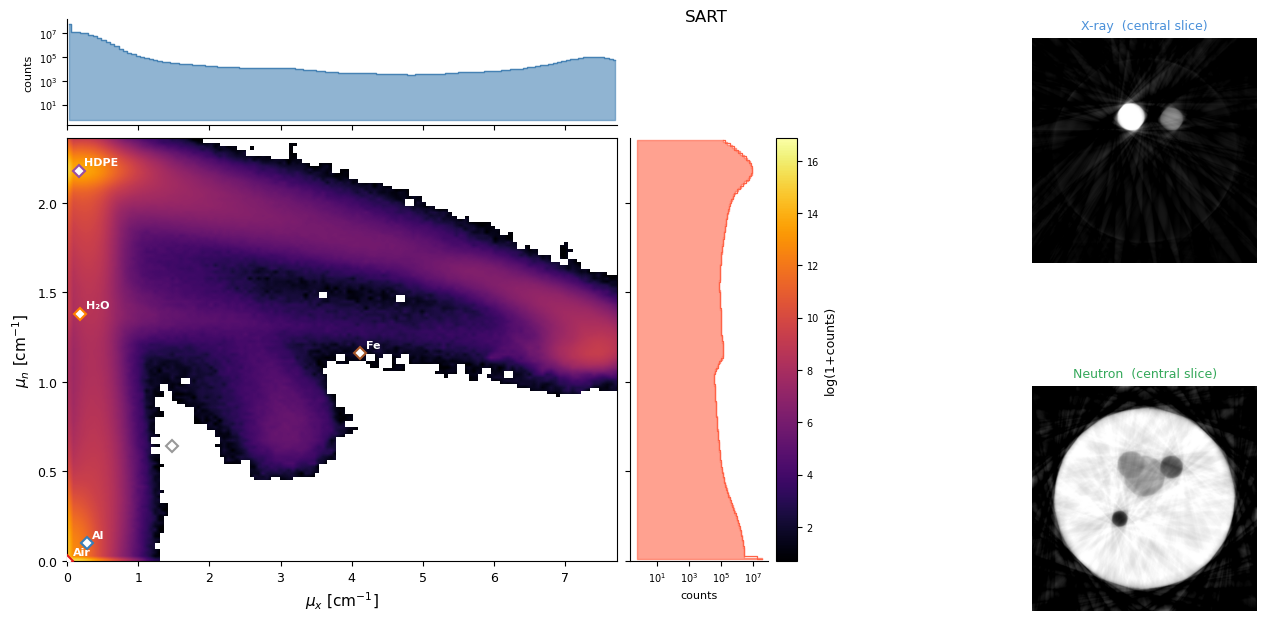

In [6]:
result = analyse_volume_pair(
    path_xray      = "/tmp3/Bimodal_simulation_data/batch_512/composite/clean/SART/vol_xray.npy",
    phantom_preset = "composite",
    phantom_N      = 512,
)

[analyse]  Loading from paths:
           X-ray  : /tmp3/Bimodal_simulation_data/batch_512/composite/clean/SART/vol_xray.npy
           Neutron: /tmp3/Bimodal_simulation_data/batch_512/composite/clean/FBP/vol_neutron.npy
[analyse]  SART
           shape=(512, 512, 512)  dtype=float32
           mu_x range [0.000, 8.630] cm^-1
           mu_n range [0.000, 2.261] cm^-1
           Building phantom 'composite' N=512…
           Computing histogram  bins=128…
           Total voxels: 134,217,728
           Fitting GMM  k=6…
           Computing metrics  (k=6)…


/tmp/ipykernel_22263/3837490376.py:175: UserWarning: GMM fitting failed: scikit-learn is required for GMM fitting: pip install scikit-learn
  warnings.warn(f"GMM fitting failed: {e}")
/tmp/ipykernel_22263/3837490376.py:202: UserWarning: Metrics failed: scikit-learn is required: pip install scikit-learn
  warnings.warn(f"Metrics failed: {e}")


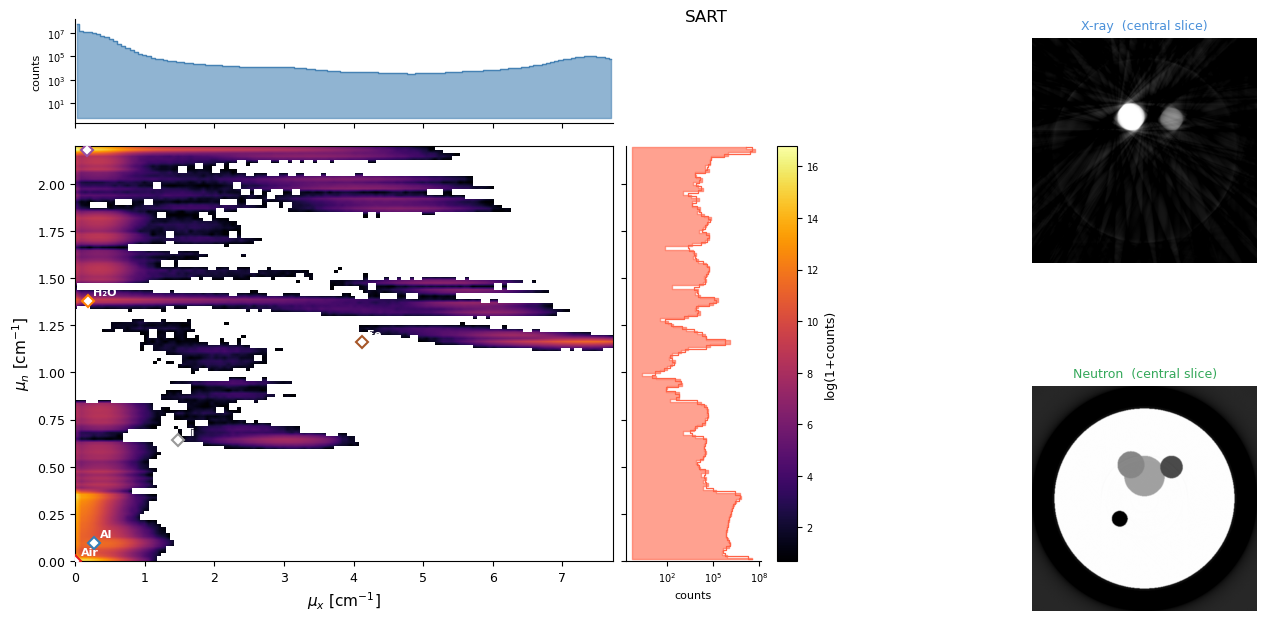

In [7]:
result = analyse_volume_pair(
    path_xray      = "/tmp3/Bimodal_simulation_data/batch_512/composite/clean/SART/vol_xray.npy",
    path_neutron   = "/tmp3/Bimodal_simulation_data/batch_512/composite/clean/FBP/vol_neutron.npy",
    phantom_preset = "composite",
    phantom_N      = 512,
)